# Práctica: Ingeniería de propiedades. Bike Rentals

1. Importación del csv

In [201]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

#Importación de librerias y lectura del dataset
df = pd.read_csv("bike_rentals.csv")
df

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,spring,2011.0,January,no,Saturday,no,Cloudy,4.110847,3.18125,80.5833,10.749882,985
1,2,spring,2011.0,January,no,Sunday,no,Cloudy,4.902598,2.68695,69.6087,16.652113,801
2,3,spring,2011.0,January,no,Monday,yes,Clear,-1.949076,-5.52975,43.7273,16.636703,1349
3,4,spring,2011.0,January,no,Tuesday,yes,Clear,-1.800000,-4.39390,59.0435,10.739832,1562
4,5,spring,2011.0,January,no,Wednesday,yes,Clear,-0.694763,-3.53650,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,spring,2012.0,December,no,Thursday,yes,Cloudy,0.420847,-3.66790,65.2917,23.458911,2114
727,728,spring,2012.0,December,no,Friday,yes,Cloudy,0.386653,-2.24770,59.0000,10.416557,3095
728,729,spring,2012.0,December,no,Saturday,no,Cloudy,0.386653,-2.88000,75.2917,8.333661,1341
729,730,spring,2012.0,December,no,Sunday,no,Clear,0.489153,-3.41500,48.3333,23.500518,1796


Revisamos que cada columna se corresponda a su tipo y los valores nulos

In [202]:
#Usamos info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   season      731 non-null    object 
 2   yr          731 non-null    float64
 3   mnth        731 non-null    object 
 4   holiday     731 non-null    object 
 5   weekday     731 non-null    object 
 6   workingday  731 non-null    object 
 7   weathersit  731 non-null    object 
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  cnt         731 non-null    int64  
dtypes: float64(5), int64(2), object(6)
memory usage: 74.4+ KB


Podemos observar que no existen valores nulos y que los tipos coinciden con cada columna. No es necesario hacer ninguna conversión.

La columna "instant" es un índice, por tanto no aporta ninguna información y procedemos a eliminarla.

In [203]:
#Eliminamos la columna "instant"
df.drop("instant", axis=1, inplace=True)
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,2011.0,January,no,Saturday,no,Cloudy,4.110847,3.18125,80.5833,10.749882,985
1,spring,2011.0,January,no,Sunday,no,Cloudy,4.902598,2.68695,69.6087,16.652113,801
2,spring,2011.0,January,no,Monday,yes,Clear,-1.949076,-5.52975,43.7273,16.636703,1349
3,spring,2011.0,January,no,Tuesday,yes,Clear,-1.800000,-4.39390,59.0435,10.739832,1562
4,spring,2011.0,January,no,Wednesday,yes,Clear,-0.694763,-3.53650,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...
726,spring,2012.0,December,no,Thursday,yes,Cloudy,0.420847,-3.66790,65.2917,23.458911,2114
727,spring,2012.0,December,no,Friday,yes,Cloudy,0.386653,-2.24770,59.0000,10.416557,3095
728,spring,2012.0,December,no,Saturday,no,Cloudy,0.386653,-2.88000,75.2917,8.333661,1341
729,spring,2012.0,December,no,Sunday,no,Clear,0.489153,-3.41500,48.3333,23.500518,1796


# 2. Datos Discretos

Hemos detectado que la columna "yr" que hace referencia al año es de tipo float. Pese a no ser un error grave y que no afectaría en nada al resultado, vamos a modificarlo.

In [204]:
# Transformamos la columna "yr" de float a int
df["yr"] = df["yr"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    object 
 1   yr          731 non-null    int64  
 2   mnth        731 non-null    object 
 3   holiday     731 non-null    object 
 4   weekday     731 non-null    object 
 5   workingday  731 non-null    object 
 6   weathersit  731 non-null    object 
 7   temp        731 non-null    float64
 8   atemp       731 non-null    float64
 9   hum         731 non-null    float64
 10  windspeed   731 non-null    float64
 11  cnt         731 non-null    int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 68.7+ KB


# 3. Fase de Codificación

En esta fase, vamos a convertir las columnas categóricas en columnas numéricas que representen a dicho valores

Columna "season". Vamos a realizar una codificación One-Hot para representar las estaciones del año.

In [205]:
# Codificamos usando One-Hot de pandas (get_dummies) la columna "season"
df = pd.get_dummies(df,columns=["season"])
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   yr             731 non-null    int64  
 1   mnth           731 non-null    object 
 2   holiday        731 non-null    object 
 3   weekday        731 non-null    object 
 4   workingday     731 non-null    object 
 5   weathersit     731 non-null    object 
 6   temp           731 non-null    float64
 7   atemp          731 non-null    float64
 8   hum            731 non-null    float64
 9   windspeed      731 non-null    float64
 10  cnt            731 non-null    int64  
 11  season_autumn  731 non-null    bool   
 12  season_spring  731 non-null    bool   
 13  season_summer  731 non-null    bool   
 14  season_winter  731 non-null    bool   
dtypes: bool(4), float64(4), int64(2), object(5)
memory usage: 65.8+ KB
None


,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,season_summer,season_winter
0,2011,January,no,Saturday,no,Cloudy,4.110847,3.18125,80.5833,10.749882,985,False,True,False,False
1,2011,January,no,Sunday,no,Cloudy,4.902598,2.68695,69.6087,16.652113,801,False,True,False,False
2,2011,January,no,Monday,yes,Clear,-1.949076,-5.52975,43.7273,16.636703,1349,False,True,False,False
3,2011,January,no,Tuesday,yes,Clear,-1.800000,-4.39390,59.0435,10.739832,1562,False,True,False,False
4,2011,January,no,Wednesday,yes,Clear,-0.694763,-3.53650,43.6957,12.522300,1600,False,True,False,False


Podemos observar que la columna "season" ha sido eliminada y se han añadido una columna booleana por cada valor (estación). Ahora transformaremos esos valores booleanos en numérico.

In [206]:
#Transformamos los valores booleanos a 0 (false) y 1 (true)
df["season_autumn"] = df["season_autumn"].astype(int)
df["season_spring"] = df["season_spring"].astype(int)
df["season_summer"] = df["season_summer"].astype(int)
df["season_winter"] = df["season_winter"].astype(int)

df.head()

,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,season_summer,season_winter
0,2011,January,no,Saturday,no,Cloudy,4.110847,3.18125,80.5833,10.749882,985,0,1,0,0
1,2011,January,no,Sunday,no,Cloudy,4.902598,2.68695,69.6087,16.652113,801,0,1,0,0
2,2011,January,no,Monday,yes,Clear,-1.949076,-5.52975,43.7273,16.636703,1349,0,1,0,0
3,2011,January,no,Tuesday,yes,Clear,-1.800000,-4.39390,59.0435,10.739832,1562,0,1,0,0
4,2011,January,no,Wednesday,yes,Clear,-0.694763,-3.53650,43.6957,12.522300,1600,0,1,0,0


Columna "holiday".

Empezamos comprobando los valores.

In [207]:
df["holiday"].value_counts()

holiday
no     710
yes     21
Name: count, dtype: int64

Puesto que solo tenemos dos valores, vamos a usar una codificación ordinal.

In [208]:
#Codificación ordinal con pandas
df["holiday"] = pd.Series.factorize(df["holiday"])[0]

In [209]:
# no -> 0 y yes -> 1
df["holiday"].value_counts()

holiday
0    710
1     21
Name: count, dtype: int64

A continuación realizamos el mismo proceso con "workingday"

In [210]:
df["workingday"].value_counts()

workingday
yes    499
no     232
Name: count, dtype: int64

In [211]:
#Transforma yes -> 1 y no -> 0
df["workingday"] =pd.Series.factorize(df["workingday"])[0]
df["workingday"].value_counts()

workingday
1    499
0    232
Name: count, dtype: int64

Columna "weathersit". En este caso también aplicacremos One-hot

In [212]:
#Comprobamos valores
df["weathersit"].value_counts()

weathersit
Clear        463
Cloudy       247
Rain/snow     21
Name: count, dtype: int64

In [213]:
#Transformamos con One-Hot
df = pd.get_dummies(df, columns=["weathersit"], dtype=int)
df.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,season_summer,season_winter,weathersit_Clear,weathersit_Cloudy,weathersit_Rain/snow
0,2011,January,0,Saturday,0,4.110847,3.18125,80.5833,10.749882,985,0,1,0,0,0,1,0
1,2011,January,0,Sunday,0,4.902598,2.68695,69.6087,16.652113,801,0,1,0,0,0,1,0
2,2011,January,0,Monday,1,-1.949076,-5.52975,43.7273,16.636703,1349,0,1,0,0,1,0,0
3,2011,January,0,Tuesday,1,-1.800000,-4.39390,59.0435,10.739832,1562,0,1,0,0,1,0,0
4,2011,January,0,Wednesday,1,-0.694763,-3.53650,43.6957,12.522300,1600,0,1,0,0,1,0,0


Vamos a hacer lo mismo para las columnas "mnth" y "weekday"

In [214]:
#Realizamos One-Hot
df = pd.get_dummies(df, columns=["weekday", "mnth"], dtype=int)
df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,...,mnth_December,mnth_February,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September
0,2011,0,0,4.110847,3.18125,80.5833,10.749882,985,0,1,...,0,0,1,0,0,0,0,0,0,0
1,2011,0,0,4.902598,2.68695,69.6087,16.652113,801,0,1,...,0,0,1,0,0,0,0,0,0,0
2,2011,0,1,-1.949076,-5.52975,43.7273,16.636703,1349,0,1,...,0,0,1,0,0,0,0,0,0,0
3,2011,0,1,-1.800000,-4.39390,59.0435,10.739832,1562,0,1,...,0,0,1,0,0,0,0,0,0,0
4,2011,0,1,-0.694763,-3.53650,43.6957,12.522300,1600,0,1,...,0,0,1,0,0,0,0,0,0,0


# 4. Transformaciones numéricas

Ahora que todas las columnas son numéricas, vamos a comenzar con las transformaciones numéricas.

In [215]:
# Mapeamos la columna "yr" a 0 y 1. Aunque esto no suponga gran cambio en la eficiencia del modelo, pero creo que es buena práctica.
# Trataremos de usar el binarizer de sklearn, aunque sería más fácil usando map de pandas.
from sklearn.preprocessing import Binarizer

b = Binarizer(threshold = 2011) #Lo que sea menor o igual que 2011 se convertirá en 0, y si es mayor en 1.
df["yr"] = b.fit_transform(df[["yr"]])
df

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,...,mnth_December,mnth_February,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September
0,0,0,0,4.110847,3.18125,80.5833,10.749882,985,0,1,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,4.902598,2.68695,69.6087,16.652113,801,0,1,...,0,0,1,0,0,0,0,0,0,0
2,0,0,1,-1.949076,-5.52975,43.7273,16.636703,1349,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,-1.800000,-4.39390,59.0435,10.739832,1562,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,0,1,-0.694763,-3.53650,43.6957,12.522300,1600,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,0,1,0.420847,-3.66790,65.2917,23.458911,2114,0,1,...,1,0,0,0,0,0,0,0,0,0
727,1,0,1,0.386653,-2.24770,59.0000,10.416557,3095,0,1,...,1,0,0,0,0,0,0,0,0,0
728,1,0,0,0.386653,-2.88000,75.2917,8.333661,1341,0,1,...,1,0,0,0,0,0,0,0,0,0
729,1,0,0,0.489153,-3.41500,48.3333,23.500518,1796,0,1,...,1,0,0,0,0,0,0,0,0,0


A continuación, buscaremos outliers en las columnas con valores continuos

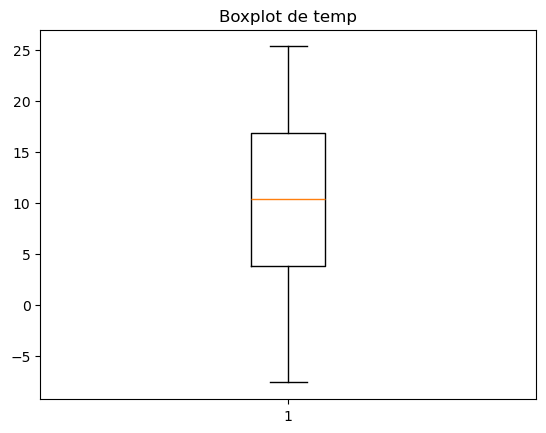

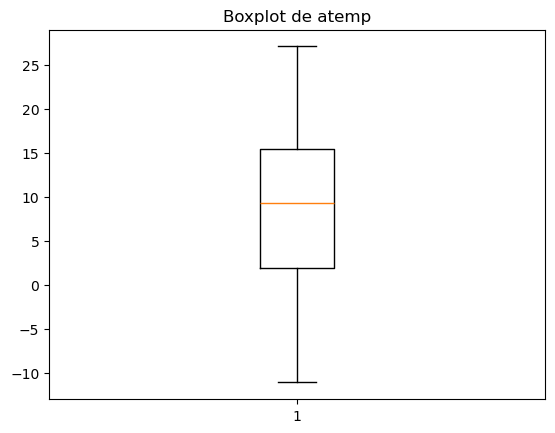

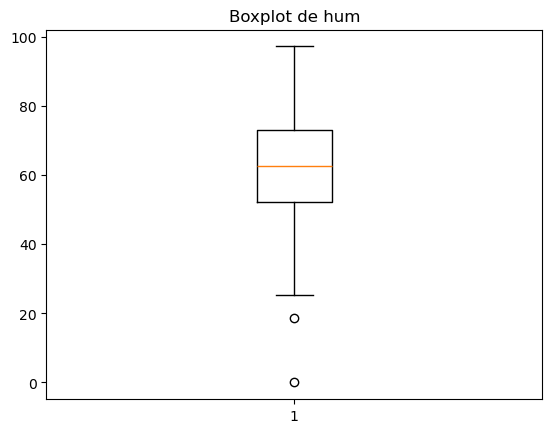

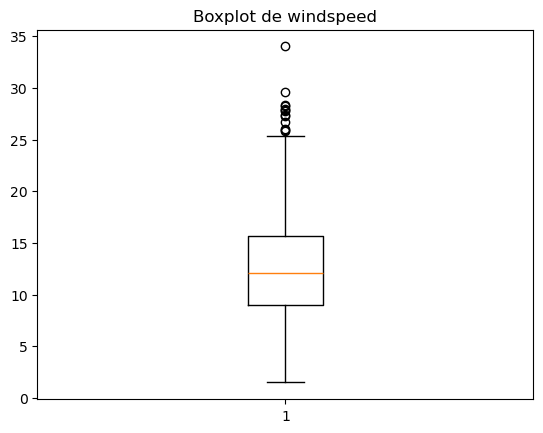

In [216]:
continuos = ["temp", "atemp", "hum", "windspeed"]

#Vamos a representar los boxplots
for c in continuos:
    bp = plt.boxplot(df[c])
    
    plt.title(f"Boxplot de {c}")
    plt.show()


Podemos observar que en la columna de windspeed ha habido días con mucho viento y existen varios outliers. Vamos a tratarlos.

Text(0.5, 1.0, 'Outliers después')

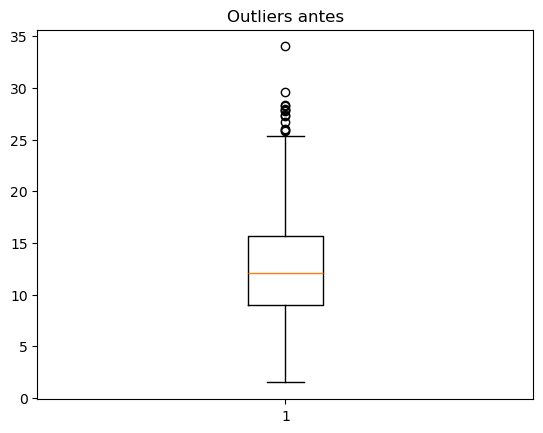

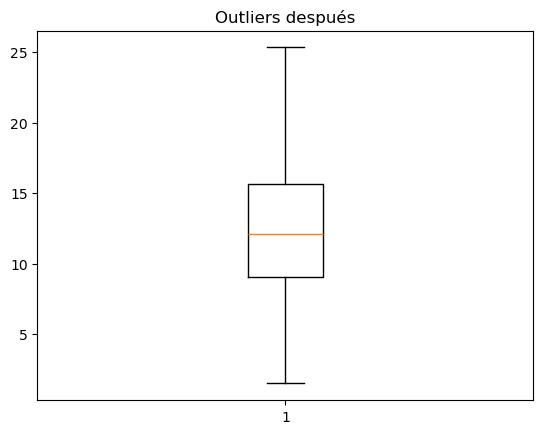

In [217]:
#En este caso, optamos por recortarlo
bp = plt.boxplot(df["windspeed"])
plt.title("Outliers antes")

#Cogemos los valores minimo y máximo
valor_min = bp["caps"][0].get_ydata()[0]
valor_max = bp["caps"][1].get_ydata()[0]
    
# Aplicamos filtro 
df.loc[df["windspeed"] > valor_max, "windspeed"] = valor_max
df.loc[df["windspeed"] < valor_min, "windspeed"] = valor_min

plt.figure()
bp = plt.boxplot(df[c])
plt.title("Outliers después")


Escalado. Ahora vamos a escalar las columnas usando MinMaxScaler, ya que tenemos columnas que ya se encuentran entre 0 y 1.

In [218]:
#Creamos el escalador
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

#Definimos las columnas a escalar 
columnas = ["temp", "atemp", "hum", "windspeed"]

#Escalamos
df[columnas] = mms.fit_transform(df[columnas])

In [219]:
df

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,...,mnth_December,mnth_February,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September
0,0,0,0,0.355170,0.373517,0.828620,0.388102,985,0,1,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0.379232,0.360541,0.715771,0.635752,801,0,1,...,0,0,1,0,0,0,0,0,0,0
2,0,0,1,0.171000,0.144830,0.449638,0.635105,1349,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0.175530,0.174649,0.607131,0.387681,1562,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,0,1,0.209120,0.197158,0.449313,0.462471,1600,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,0,1,0.243025,0.193709,0.671380,0.921356,2114,0,1,...,1,0,0,0,0,0,0,0,0,0
727,1,0,1,0.241986,0.230993,0.606684,0.374116,3095,0,1,...,1,0,0,0,0,0,0,0,0,0
728,1,0,0,0.241986,0.214393,0.774208,0.286721,1341,0,1,...,1,0,0,0,0,0,0,0,0,0
729,1,0,0,0.245101,0.200348,0.497001,0.923102,1796,0,1,...,1,0,0,0,0,0,0,0,0,0


# Modelo de predicción

A continuación, usaremos un modelo de arbol de decisiones para realizar una regresión.

In [220]:
from sklearn.model_selection import train_test_split
#Hacemos train_test_split
X = df.drop("cnt", axis=1)
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [221]:
#Ahora con linear regression
from sklearn.linear_model import LinearRegression

#Modelo
lr = LinearRegression()
#Entrenamos
lr.fit(X_train, y_train)

print("Score del train", lr.score(X_train, y_train))
print("Score del test", lr.score(X_test, y_test))

Score del train 0.8534054202254183
Score del test 0.8158879623423355


Red neuronal

In [222]:
#Probamos con una red neuronal
#Para este caso, también debemos escalar la variable objetivo
df["cnt"] = mms.fit_transform(df[["cnt"]])

In [223]:
df

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_autumn,season_spring,...,mnth_December,mnth_February,mnth_January,mnth_July,mnth_June,mnth_March,mnth_May,mnth_November,mnth_October,mnth_September
0,0,0,0,0.355170,0.373517,0.828620,0.388102,0.110792,0,1,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0.379232,0.360541,0.715771,0.635752,0.089623,0,1,...,0,0,1,0,0,0,0,0,0,0
2,0,0,1,0.171000,0.144830,0.449638,0.635105,0.152669,0,1,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0.175530,0.174649,0.607131,0.387681,0.177174,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,0,1,0.209120,0.197158,0.449313,0.462471,0.181546,0,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,0,1,0.243025,0.193709,0.671380,0.921356,0.240681,0,1,...,1,0,0,0,0,0,0,0,0,0
727,1,0,1,0.241986,0.230993,0.606684,0.374116,0.353543,0,1,...,1,0,0,0,0,0,0,0,0,0
728,1,0,0,0.241986,0.214393,0.774208,0.286721,0.151749,0,1,...,1,0,0,0,0,0,0,0,0,0
729,1,0,0,0.245101,0.200348,0.497001,0.923102,0.204096,0,1,...,1,0,0,0,0,0,0,0,0,0


In [224]:
X_train.shape[1]

33

In [225]:
#Creamos la red
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

propiedades = X_train.shape[1]

red = Sequential(name = "bicis")

#Capa oculta + entrada
red.add(Dense(70, activation="relu", input_shape=(propiedades,)))
# 70 neuronas ya que seguimos la regla de Kolmogorov-Arnold

#Capa de salida
red.add(Dense(1, activation="linear"))

#Compilamos
red.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [226]:
red.summary()

Model: "bicis"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 70)             │         2,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,451 (9.57 KB)

 Trainable params: 2,451 (9.57 KB)

 Non-trainable params: 0 (0.00 B)

In [227]:
#Escalamos la y_train e y_test
y_train_escalado = mms.fit_transform(y_train.values.reshape(-1,1))
y_test_escalado = mms.fit_transform(y_test.values.reshape(-1,1))

In [228]:
h = red.fit(
    X_train, y_train_escalado,
    epochs=100,
    batch_size = 15,
    verbose = False,
    validation_data=(X_test, y_test_escalado)
)

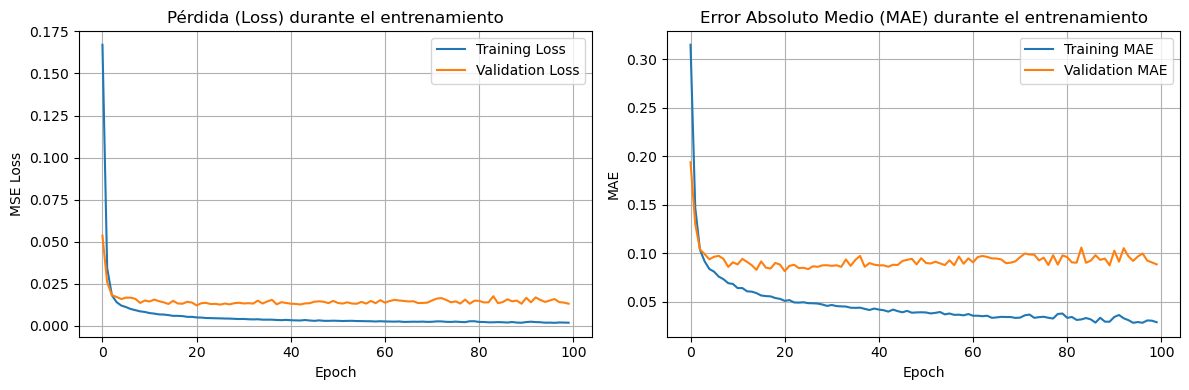

In [229]:
# Representar el histórico de entrenamiento
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Training Loss')
plt.plot(h.history['val_loss'], label='Validation Loss')
plt.title('Pérdida (Loss) durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid()

# MAE
plt.subplot(1, 2, 2)
plt.plot(h.history['mae'], label='Training MAE')
plt.plot(h.history['val_mae'], label='Validation MAE')
plt.title('Error Absoluto Medio (MAE) durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


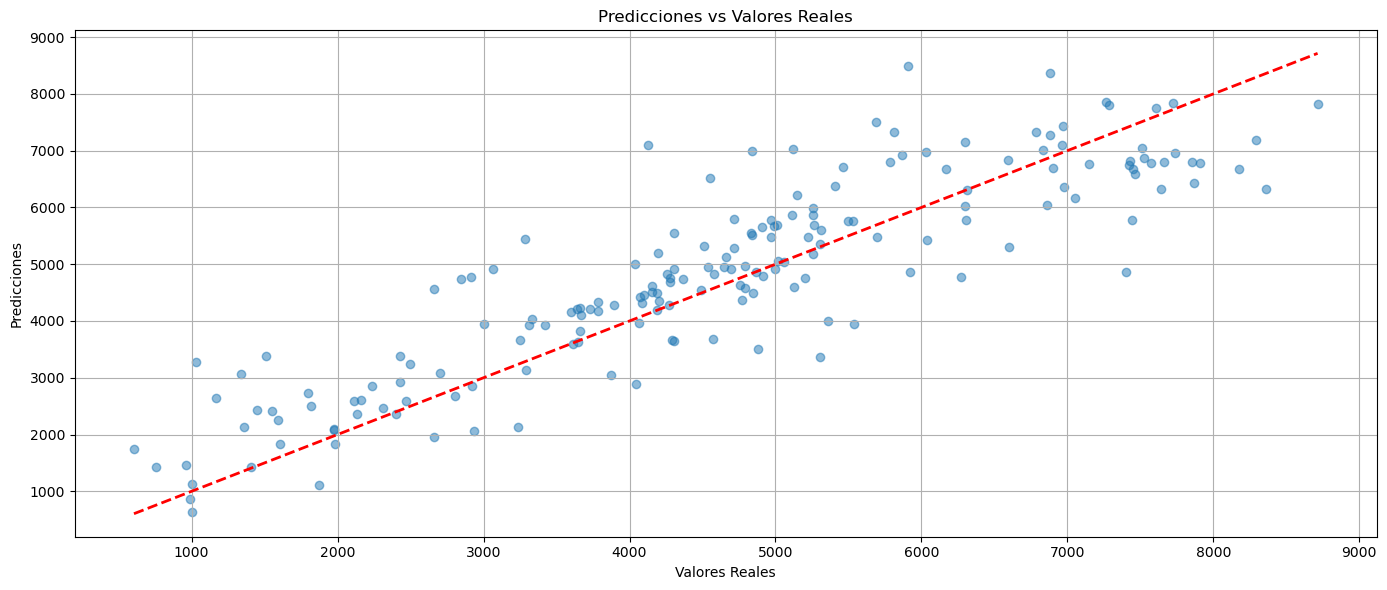

In [230]:
# Comparar predicciones con valores reales
y_pred_escalado = red.predict(X_test)
y_pred = mms.inverse_transform(y_pred_escalado)

plt.figure(figsize=(14, 6))

# Gráfico 1: Predicciones vs Valores Reales (scatter plot)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid()

plt.tight_layout()
plt.show()

In [231]:
print("Score de la red con train", red.evaluate(X_train, y_train))
print("Score de la red con test", red.evaluate(X_test, y_test))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23727564.0000 - mae: 4468.0288  
Score de la red con train [23727564.0, 4468.02880859375]
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24941268.0000 - mae: 4611.0708 
Score de la red con test [24941268.0, 4611.07080078125]


In [232]:
# Calcular el R² para el conjunto de prueba
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R² de la red neuronal en el conjunto de prueba: {r2}")

R² de la red neuronal en el conjunto de prueba: 0.7654529213905334
